In [1]:
# carga de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib



Dataset: Breast Cancer Wisconsin (scikit-learn)
Flujo:

1. Estandarización

2. PCA

3. KMeans
4. Evaluación de clusters

5. Predicción de nuevos datos

6. Persistencia del modelo

7. Reutilización del modelo guardado

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # Solo para referencia clínica (no se usa en KMeans)

print(X.shape)
X.head()

random_state = 42

(569, 30)


In [3]:
# estandarizacion de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


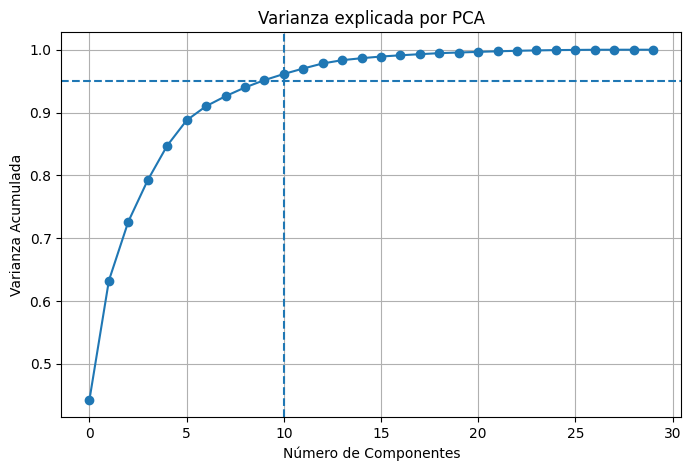

In [ ]:
# PCA
pca = PCA(n_components=None, random_state=random_state)
X_pca_full = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Elegimos k componentes para explicar al menos 95% de la varianza
threshold = 0.95
k_95 = int(np.argmax(explained_variance >= threshold) + 1)

plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker='o')
plt.axhline(threshold, linestyle="--")
plt.axvline(k_95, linestyle="--")
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza explicada por PCA')
plt.grid()
plt.show()


In [12]:
# seleccion de componentes
n_components = np.argmax(explained_variance >= 0.95) + 1
print("Componentes para 95% varianza:", n_components)

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)


Componentes para 95% varianza: 10


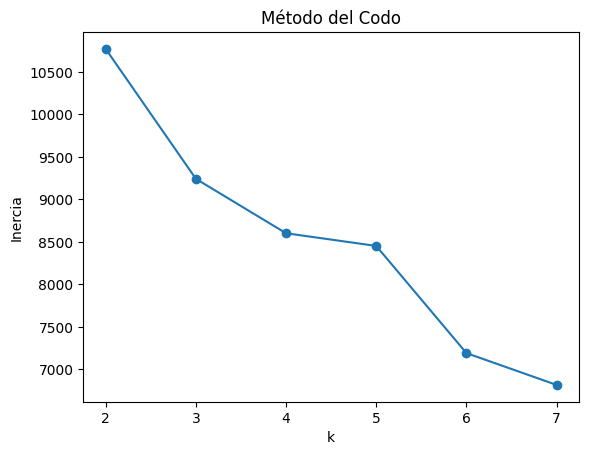

k=2, Silhouette=0.358
k=3, Silhouette=0.327
k=4, Silhouette=0.249
k=5, Silhouette=0.187
k=6, Silhouette=0.179
k=7, Silhouette=0.181


In [13]:
# clustering con KMeans
# metodo del codo
inertia = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

# silhouette score
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    print(f"k={k}, Silhouette={silhouette_score(X_pca, labels):.3f}")

# suponemos k=2
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca)


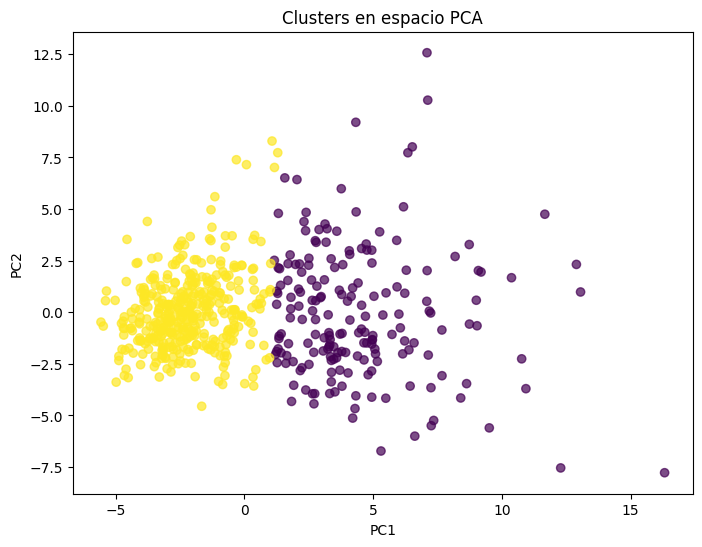

In [14]:
# visualizacion espacio PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters en espacio PCA')
plt.show()


In [15]:
# pipeline para produccion
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components)),
    ('kmeans', KMeans(n_clusters=2, random_state=42))
])

pipeline.fit(X)

# prediccion nuevos datos
nuevo_paciente = X.iloc[[0]]  # Simulación

cluster_pred = pipeline.predict(nuevo_paciente)
print("Cluster asignado:", cluster_pred)


Cluster asignado: [0]


In [16]:
# guardar el modelo
joblib.dump(pipeline, "modelo_pca_kmeans_breast_cancer.pkl")
print("Modelo guardado")

# reutilizacion del modelo
modelo_cargado = joblib.load("modelo_pca_kmeans_breast_cancer.pkl")

nuevo = X.iloc[[10]]
pred = modelo_cargado.predict(nuevo)

print("Predicción con modelo cargado:", pred)


Modelo guardado
Predicción con modelo cargado: [1]


| Etapa              | Rol en sistema real biomédico |
| ------------------ | ----------------------------- |
| **StandardScaler** | Normaliza mediciones clínicas |
| **PCA**            | Reduce ruido y colinealidad   |
| **KMeans**         | Detecta subtipos de pacientes |
| **Pipeline**       | Reproducibilidad              |
| **Persistencia**   | Despliegue en hospital / API  |

Este patrón se usa en:

- Estratificación de pacientes

- Segmentación de perfiles tumorales

- Reducción de biomarcadores redundantes

- Preprocesamiento antes de modelos supervisados
